In [14]:
import scanpy as scp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [15]:
adata = scp.read("results/Raw.h5ad")

# QC measures

In [16]:
adata.obs["counts"] = adata.X.sum(axis=1)
adata.obs["genes"] = (adata.X > 0).sum(axis=1)
mtgenes = ["mt-" in i for i in adata.var["gene_name"]]
adata.obs["mtFraction"] = (adata[:,mtgenes].X).sum(axis=1)
adata.obs["mtFraction"] /= adata.obs["counts"].values

## Total

<AxesSubplot:xlabel='counts', ylabel='genes'>

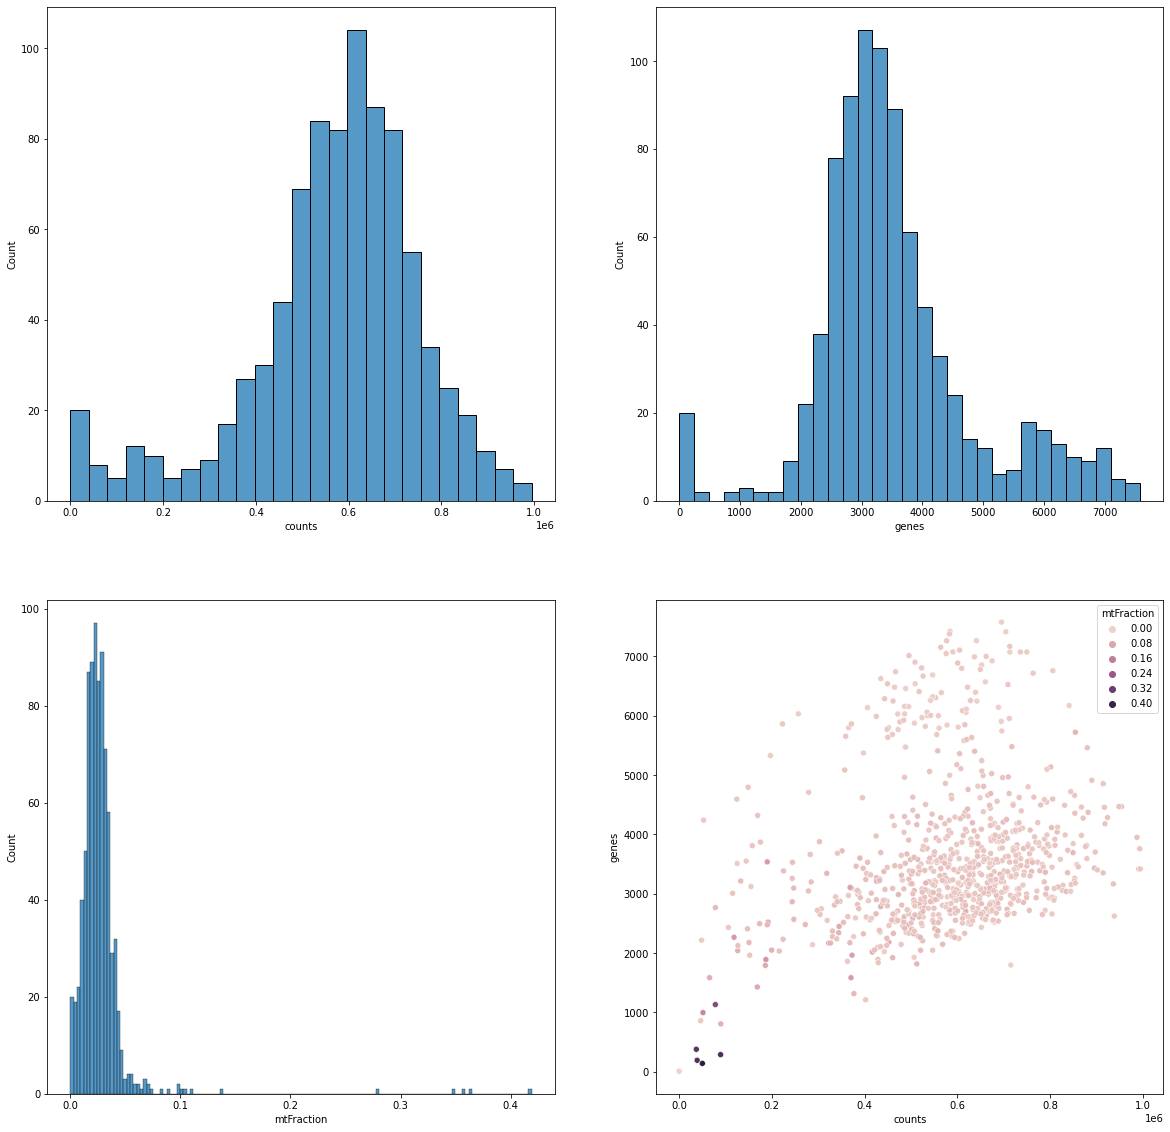

In [17]:
fig,ax = plt.subplots(2,2,figsize=[20,20])

sns.histplot(data=adata.obs,x="counts",ax=ax[0,0])
sns.histplot(data=adata.obs,x="genes",ax=ax[0,1])
sns.histplot(data=adata.obs,x="mtFraction",ax=ax[1,0])
sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="mtFraction",ax=ax[1,1])

## By times

In [18]:
adata.obs.columns

Index(['Cell', 'Time', 'Condition', 'BiologicalSample', 'Lane',
       'All Events #Events', 'All Events %Parent', 'All Events FSC-A Median',
       'All Events FSC-H Median', 'All Events FSC-W Median',
       'All Events SSC-A Median', 'All Events SSC-H Median',
       'All Events SSC-W Median', 'All Events GFP FLK-1 530/30 Blue-A Median',
       'All Events 582/15 Y/G-A Median',
       'All Events PE Dazzle 594 CD41 610/20 Y/G-A Median',
       'All Events PECy7 Sca-1 780/60 Y/G-A Median',
       'All Events APC CD45 660/20 Red-A Median',
       'All Events APCCy7 cKIT 780/60 Red-A Median',
       'All Events Hoechst 58 450/40 Violet-A Median',
       'All Events Time Median', 'counts', 'genes', 'mtFraction'],
      dtype='object')

<AxesSubplot:xlabel='Time', ylabel='genes'>

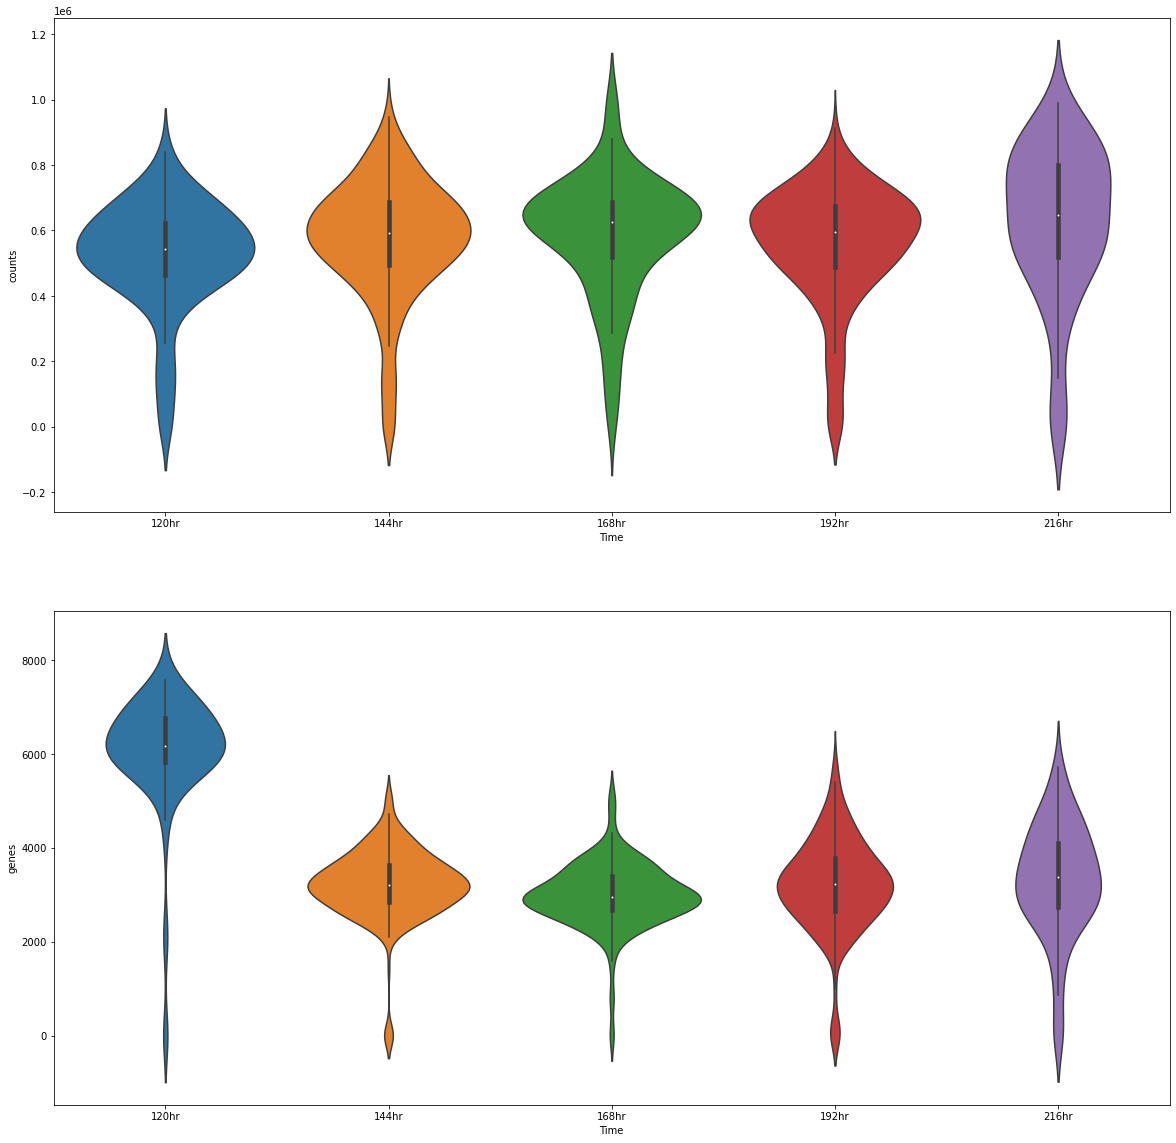

In [19]:
fig,ax = plt.subplots(2,1,figsize=[20,20])

sns.violinplot(data=adata.obs,x="Time",y="counts",ax=ax[0])
sns.violinplot(data=adata.obs,x="Time",y="genes",ax=ax[1])

<AxesSubplot:xlabel='BiologicalSample', ylabel='genes'>

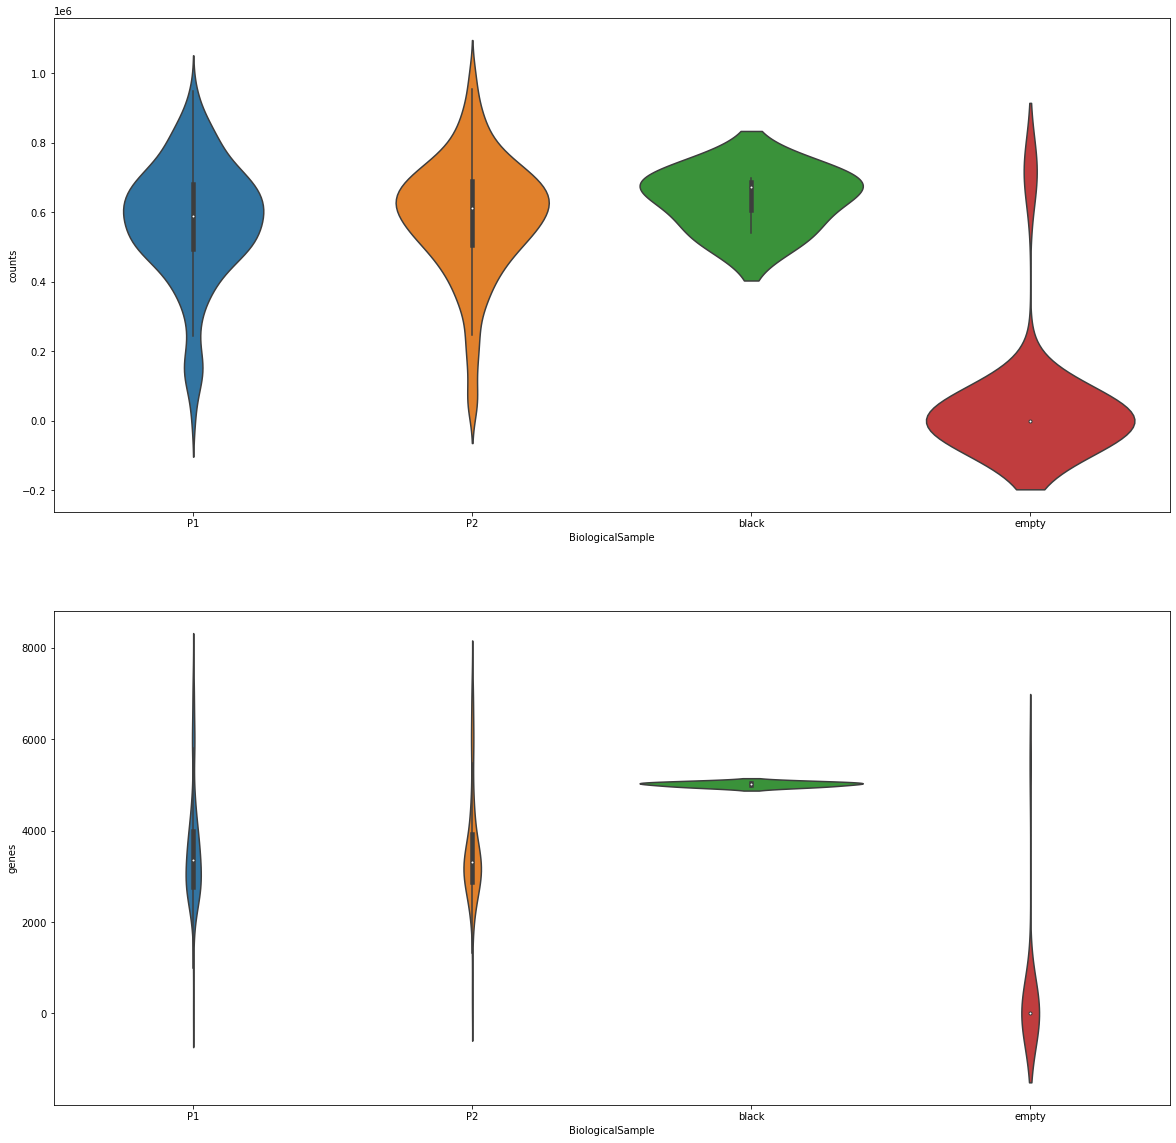

In [20]:
fig,ax = plt.subplots(2,1,figsize=[20,20])

sns.violinplot(data=adata.obs,x="BiologicalSample",y="counts",ax=ax[0])
sns.violinplot(data=adata.obs,x="BiologicalSample",y="genes",ax=ax[1])

<AxesSubplot:xlabel='Condition', ylabel='genes'>

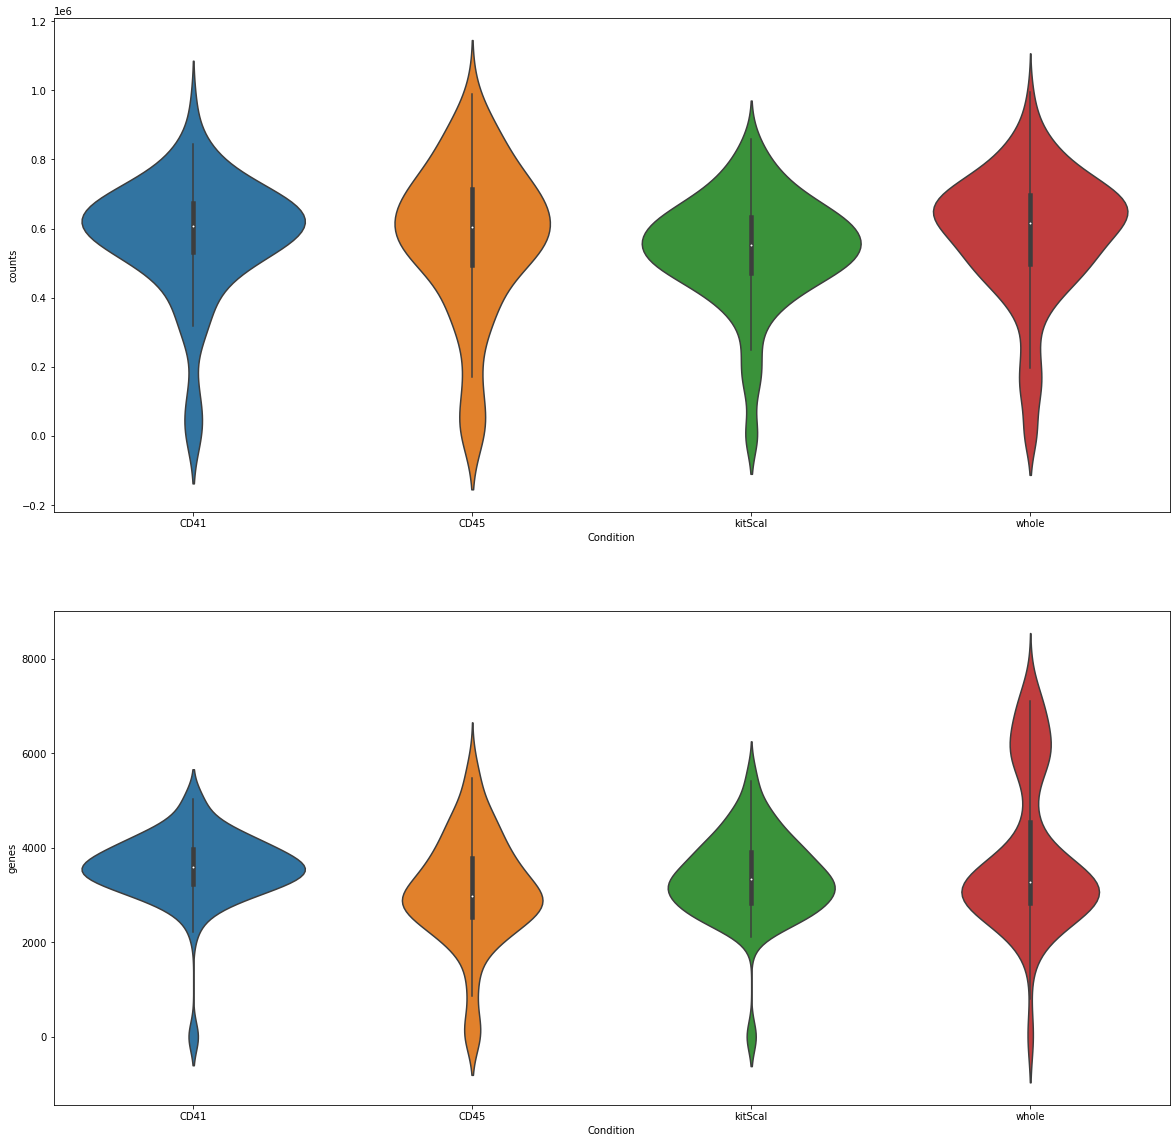

In [21]:
fig,ax = plt.subplots(2,1,figsize=[20,20])

sns.violinplot(data=adata.obs,x="Condition",y="counts",ax=ax[0])
sns.violinplot(data=adata.obs,x="Condition",y="genes",ax=ax[1])

# Understanding the bimodality

The bimodality in the scatterplot coomes from sequenced whole gastruloids at 120h. The bimodality may come probably for a more variability in the gene expression due to the variability of the gastruloid expression.

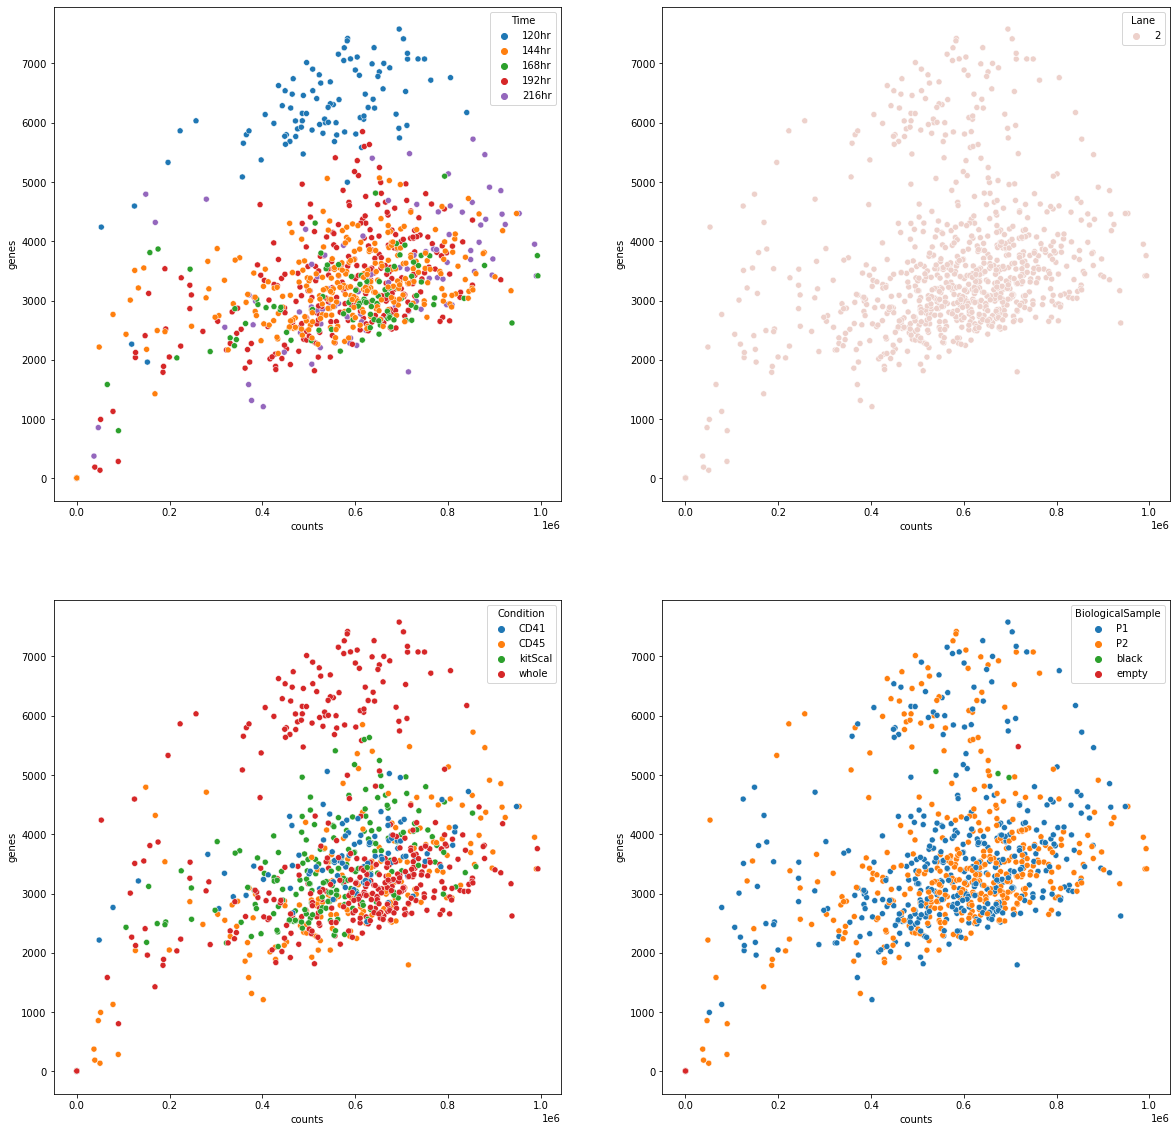

In [22]:
fig,ax = plt.subplots(2,2,figsize=[20,20])

sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="Time",ax=ax[0,0])
sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="Lane",ax=ax[0,1])
sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="Condition",ax=ax[1,0])
sns.scatterplot(data=adata.obs,y="genes",x="counts",hue="BiologicalSample",ax=ax[1,1])

fig.savefig("plots/Bimodality_scatter.png",bbox_inches="tight")

# Filter cells and save

In [25]:
shape = adata.shape

scp.pp.filter_cells(adata,min_counts=200000)
scp.pp.filter_genes(adata,min_cells=1)
adata = adata[adata.obs["mtFraction"]<0.2,:]

print("Cells retained after cutoffs: ",adata.shape[0],"/",shape[0]," (",np.round(100*adata.shape[0]/shape[0],2),"%)")
print("Genes that are expressed at least in one cell: ",adata.shape[1],"/",shape[1]," (",np.round(100*adata.shape[1]/shape[1],2),"%)")

Trying to set attribute `.obs` of view, copying.


Cells retained after cutoffs:  801 / 801  ( 100.0 %)
Genes that are expressed at least in one cell:  28286 / 28286  ( 100.0 %)


In [26]:
adata.write("results/QC.h5ad")